In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import models
import matplotlib.pyplot as plt
import os

In [2]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
NUM_CLASSES = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

#Download and load the FashionMNIST training data
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

#Download and load the FashionMNIST test data
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 60000
Number of test samples: 10000


In [4]:
model_froz = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_froz.parameters():
    param.requires_grad = False

num_ftrs = model_froz.fc.in_features
model_froz.fc = nn.Linear(num_ftrs, NUM_CLASSES)

model_froz = model_froz.to(device)
# print(model_froz)

In [5]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, NUM_CLASSES)

model_ft = model_ft.to(device)
# print(model_ft)

In [6]:
criterion = nn.CrossEntropyLoss()
froz_optimizer = optim.Adam(model_froz.fc.parameters(), lr=LEARNING_RATE)
ft_optimizer = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': LEARNING_RATE},
    {'params': model_ft.fc.parameters(), 'lr': LEARNING_RATE}
])

In [7]:
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [8]:
def train(model, train_loader, criterion, optimizer, device, num_epochs = 5):
    model.train()
    train_losses = []
    test_acc = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        acc = evaluate(model, test_loader, device)
        test_acc.append(acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Test Acc: {acc:.2f}%")
    return train_losses, test_acc

In [9]:
def show_examples(model, test_loader, device, model_name):
    model.eval()
    correct = []
    incorrect = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                img = inputs[i].cpu()
                label = labels[i].item()
                pred = preds[i].item()

                if label == pred and len(correct) < 3:
                    correct.append((img, label, pred))
                elif label != pred and len(incorrect) < 3:
                    incorrect.append((img, label, pred))

                if len(correct) == 3 and len(incorrect) == 3:
                    break
            if len(correct) == 3 and len(incorrect) == 3:
                break

    class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    def imshow(img):
        img = img.numpy().transpose((1,2,0))
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        img = std * img + mean
        img = img.clip(0,1)
        plt.imshow(img)

    plt.figure(figsize=(10,6))

    for i, (img, label, pred) in enumerate(correct):
        plt.subplot(2,3,i+1)
        imshow(img)
        plt.title(f"{model_name}\nCORRECT\nT:{class_names[label]}\nP:{class_names[pred]}")
        plt.axis('off')

    for i, (img, label, pred) in enumerate(incorrect):
        plt.subplot(2,3,i+4)
        imshow(img)
        plt.title(f"{model_name}\nWRONG\nT:{class_names[label]}\nP:{class_names[pred]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
print("Training model A (all params frozen except final fully connected layer)...")
losses_froz, accs_froz = train(model_froz, train_loader, criterion, froz_optimizer, device, num_epochs=NUM_EPOCHS)
final_acc_froz = evaluate(model_froz, test_loader, device)
print(f"Accuracy on frozen model A: {final_acc_froz:.2f}%")

Training model A (all params frozen except final fully connected layer)...
Epoch 1/5, Loss: 0.6015, Test Acc: 84.52%
Epoch 2/5, Loss: 0.4126, Test Acc: 85.08%
Epoch 3/5, Loss: 0.3847, Test Acc: 86.02%
Epoch 4/5, Loss: 0.3692, Test Acc: 86.16%
Epoch 5/5, Loss: 0.3581, Test Acc: 86.27%
Accuracy on frozen model A: 86.27%


In [11]:
print("Training model B (all params frozen except last residual block and final fully connected layer)...")
losses_ft, accs_ft = train(model_ft, train_loader, criterion, ft_optimizer, device, num_epochs=NUM_EPOCHS)
final_acc_ft = evaluate(model_ft, test_loader, device)
print(f"Accuracy on model B (fine tune last residual block): {final_acc_ft:.2f}%")

Training model B (all params frozen except last residual block and final fully connected layer)...
Epoch 1/5, Loss: 0.2793, Test Acc: 91.00%
Epoch 2/5, Loss: 0.2058, Test Acc: 91.86%
Epoch 3/5, Loss: 0.1570, Test Acc: 92.78%
Epoch 4/5, Loss: 0.1212, Test Acc: 92.32%
Epoch 5/5, Loss: 0.0949, Test Acc: 92.83%
Accuracy on model B (fine tune last residual block): 92.83%


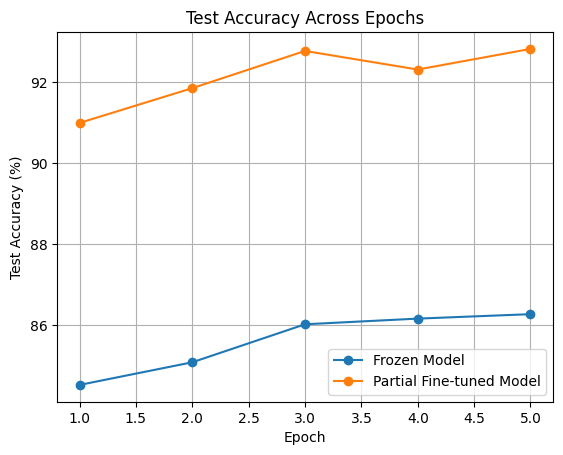

In [12]:
plt.figure()
plt.plot(range(1, NUM_EPOCHS+1), accs_froz, marker='o', label='Frozen Model')
plt.plot(range(1, NUM_EPOCHS+1), accs_ft, marker='o', label='Partial Fine-tuned Model')
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across Epochs")
plt.legend()
plt.grid()
plt.show()

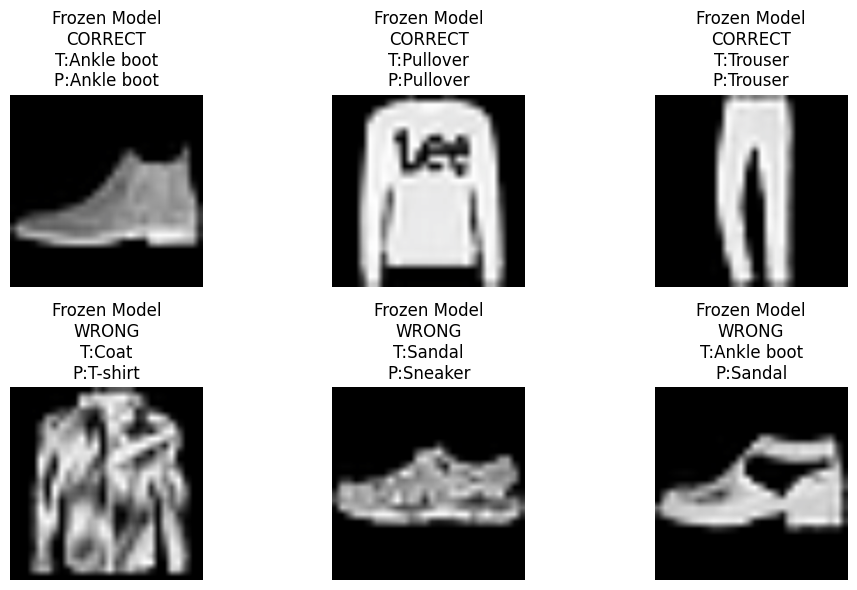

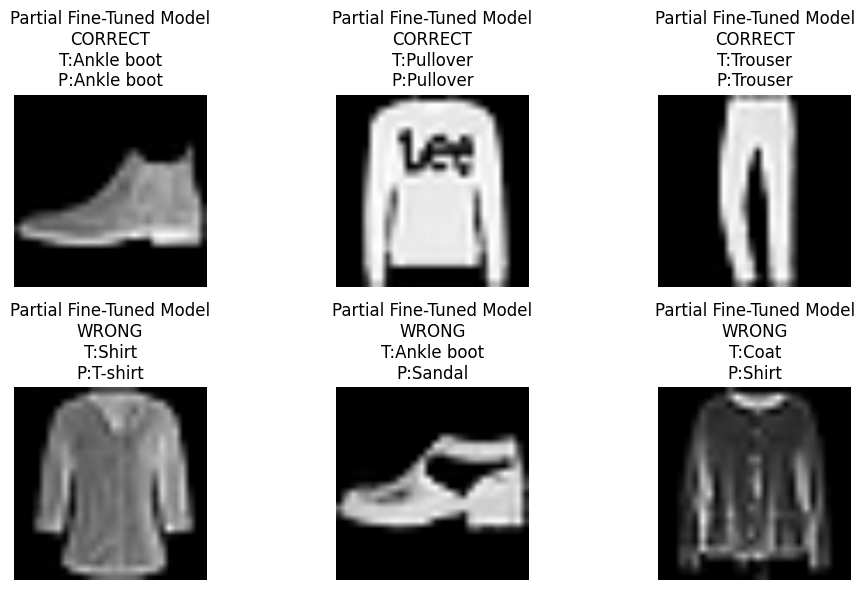

In [13]:
show_examples(model_froz, test_loader, device, "Frozen Model")
show_examples(model_ft, test_loader, device, "Partial Fine-Tuned Model")